In [ ]:
import scipy.signal as sig
import numpy as np 
import matplotlib.pyplot as plt
import sounddevice as sd

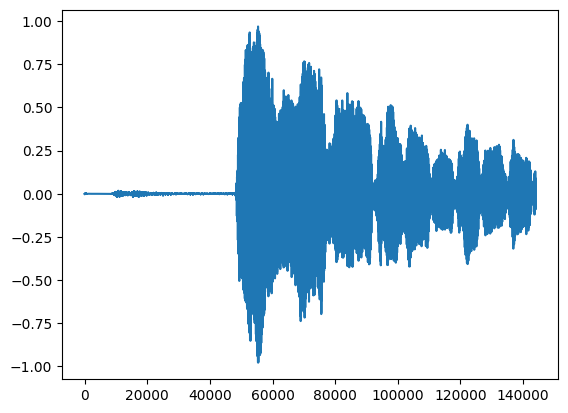

In [13]:
# fs = 44100  # Sample rate given in sounddevice example 
fs = 48e3
seconds = 3  # Duration of recording

myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()  # Wait until recording is finished
plt.plot(myrecording)

This vocoder implements an  LCCDE representing transfer function

https://www.quantum-machines.co/blog/introduction-to-digital-filters-01-first-things-first/

$$ \begin{equation}
    H(z)  = \frac{\sum_{k=0}^N b_k z^{-k}}{\sum_{k=1}^M a_k z^{-k}}
    \end{equation}
$$


Human voice frequencies: human vocal range 

Total bandwidth: 50Hz-7kHz. Split equally in three to start. 
Procedure is to filter the microphone input (voice) and filter the sawtooth (pitch) with B1. Then mix the results. Repeat the same for B2 and B3. Add all the mixed signals together to produce the output
The sawtooth is produced by 

In [15]:
fmin = 50
fmax = 7e3
segment = (fmax-fmin)/3 # divide bandwidth equally into three segments 
band1 = fmin + segment
band2 = band1 + segment
band3 = band2 + segment

<StemContainer object of 3 artists>

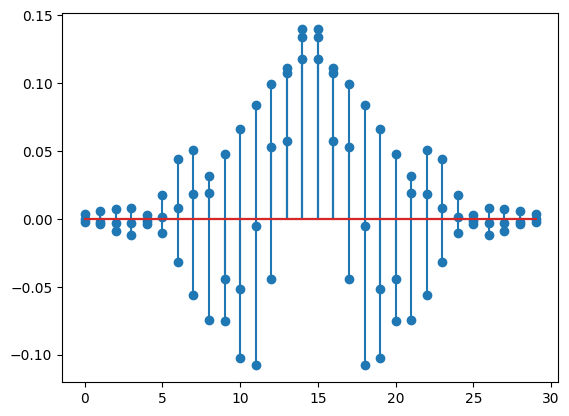

In [ ]:
# Choose number of filter taps 
Ntaps = 30

# Extract FIR bandpass filter coefficients for each bandwidth
fir_b1 = np.array(sig.firwin(Ntaps, cutoff=[fmin, band1], pass_zero='bandpass', fs=fs)) # cutoff should correspond with -6dB 
fir_b2 = np.array(sig.firwin(Ntaps, cutoff=[band1, band2], pass_zero='bandpass', fs=fs)) 
fir_b3 = np.array(sig.firwin(Ntaps, cutoff=[band2, band3], pass_zero='bandpass', fs=fs)) 
plt.stem(fir_b1)
plt.stem(fir_b2)
plt.stem(fir_b3)

In [39]:
# Create a test sinusoid 
f0 = 80e3
A = 5
phi = 0
n = np.arange(0, 100)
x = A*np.cos(2*np.pi*(f0/fs)*n+phi)

# Calculate filtering action using lfilter function 
mic_fir_1 = sig.lfilter(fir_b1, a=[1], x=x)
mic_fir_2 = sig.lfilter(fir_b2, a=[1], x=x)
mic_fir_3 = sig.lfilter(fir_b3, a=[1], x=x)

# Calculate filtering action by convolution 
mic_conv_1 = np.convolve(x, fir_b1)
mi_conv_2 = np.convolve(x, fir_b2)
mic_conv_3 = np.convolve(x, fir_b3)



Text(0.5, 1.0, 'lfilter')

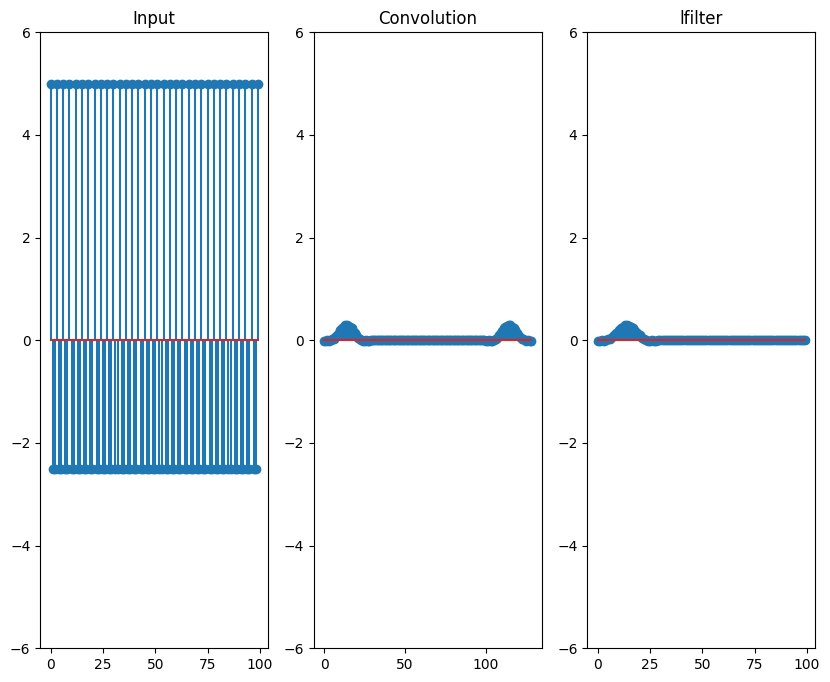

In [40]:
fig, ax = plt.subplots(1,3, figsize=(10, 8))
ax[0].stem(n, x)
ax[0].set_ylim([-6, 6])
ax[0].set_title('Input')

ax[1].stem(mic_conv_1)
ax[1].set_title('Convolution')
ax[1].set_ylim([-6, 6])

ax[2].stem(mic_fir_1)
ax[2].set_ylim([-6, 6])
ax[2].set_title('lfilter')

Text(0.5, 1.0, 'lfilter')

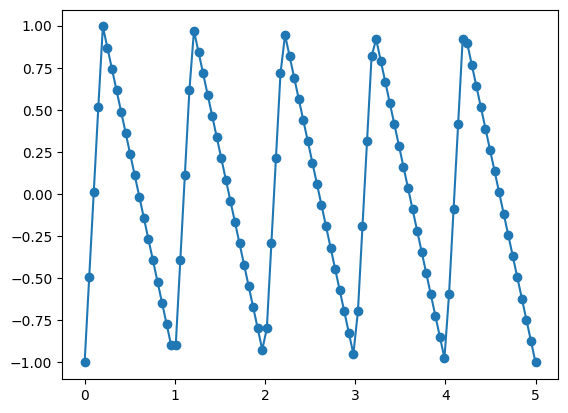

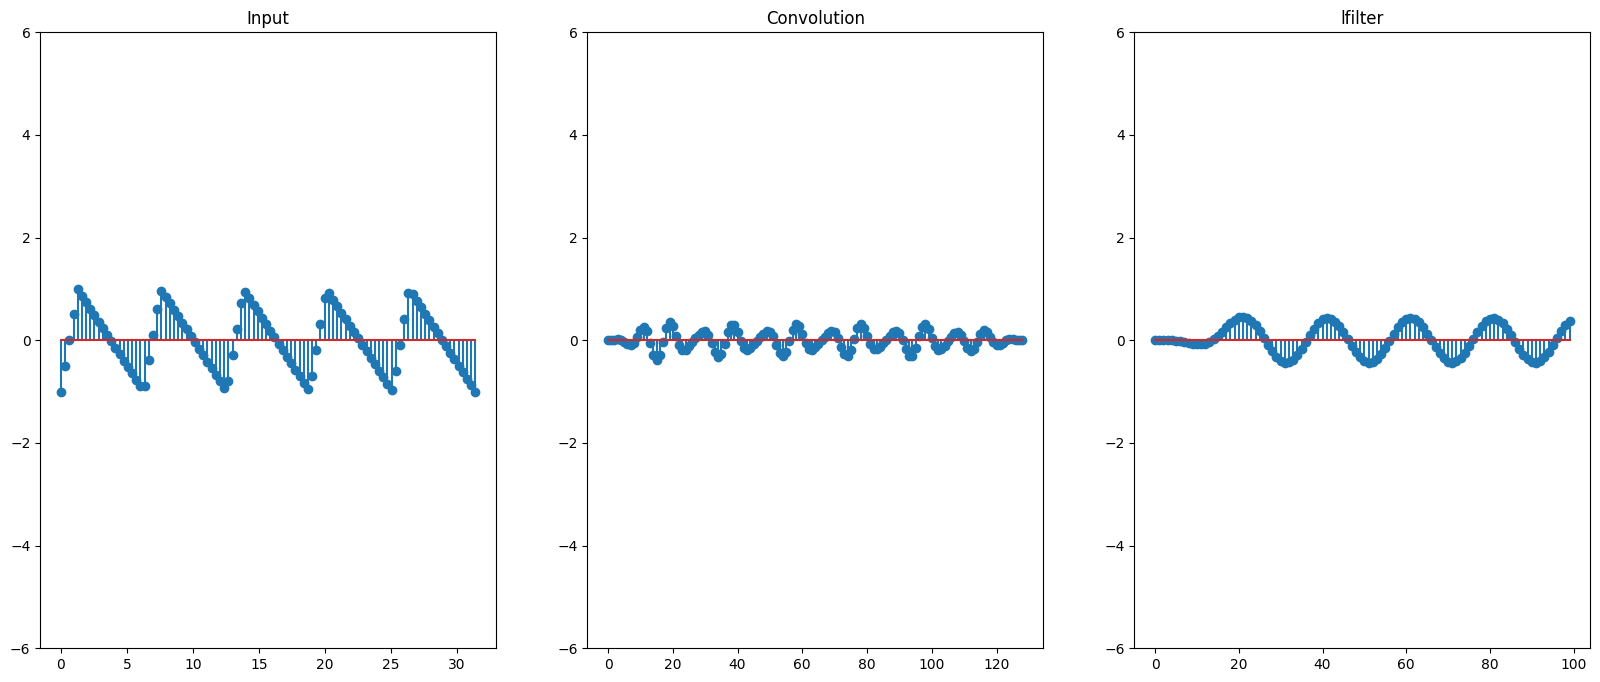

In [41]:
periods = 5
samples = 100
n = np.linspace(0, periods*2*np.pi, samples)
pitch = sig.sawtooth(n, 0.2)
plt.plot(n/(2*np.pi), pitch, '-o')

# Calculate filtering action using lfilter function 
pitch_fir_1 = sig.lfilter(fir_b1, a=[1], x=pitch)
pitch_fir_2 = sig.lfilter(fir_b2, a=[1], x=pitch)
pitch_fir_3 = sig.lfilter(fir_b3, a=[1], x=pitch)

# Calculate filtering action by convolution 
pitch_conv_1 = np.convolve(pitch, fir_b1)
pitch_conv_2 = np.convolve(pitch, fir_b2)
pitch_conv_3 = np.convolve(pitch, fir_b3)

fig, ax = plt.subplots(1,3, figsize=(20, 8))
ax[0].stem(n, pitch)
ax[0].set_ylim([-6, 6])
ax[0].set_title('Input')

ax[1].stem(pitch_conv_3)
ax[1].set_title('Convolution')
ax[1].set_ylim([-6, 6])

ax[2].stem(pitch_fir_1)
ax[2].set_ylim([-6, 6])
ax[2].set_title('lfilter')

   From sawtooth docs: Note that this is not band-limited.  It produces an infinite number
    of harmonics, which are aliased back and forth across the frequency
    spectrum.

* compare 31 tap with 3 tap, IIR vs FIR 

* choose cutoff frequency, define lowpass filter as stepwise function on domain -pi to pi 
* build bandpass as a combination of low pass filters 
* the inverse transform will be some combination of shifted sinc functions. 
* window it to get an FIR filter but consider the trade offs: linear phase vs a lot of memory (nonlinear distortion) -> should we go for a lot of memory 
* choose a filter type (FIR filter) -> probably type 1 filter (from the tutorial, general can be any) OR we may have to do IIR (feedback makes it highly linear but stability issues)
* go to the LCCDE 
* for fun draw the block diagram 
* choose the number of taps in the fiter 

In [ ]:
fs = 200e3
f0 = 10e3
A = 5
phi = 10

n = np.arange(0, 100)

x = A*np.cos(2*np.pi*(f0/fs)*n+phi)

b = [1, 0.5]
a = [1, 0.6]


y1 = sig.lfilter(b, a, x)

w, Hw =  sig.freqz(b, a)

# w is in rad/sample; one radian is pi

# y2 = abs(Hw)*A*np.cos(2*np.pi*(f0/fs)*n+phi + np.arg(Hw))



What does it mean that the thing is in radians per sample? 

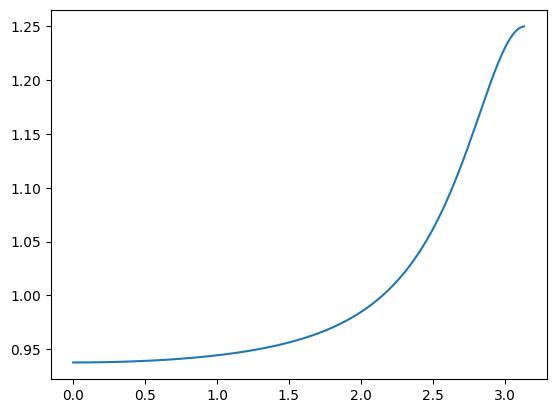

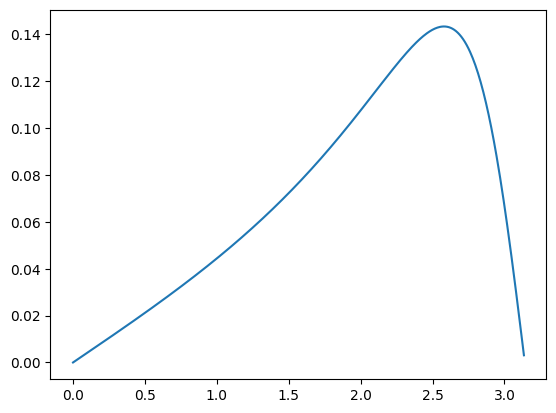

In [27]:
plt.plot(w, abs(Hw))
plt.figure()
plt.plot(w, np.angle(Hw))

<StemContainer object of 3 artists>

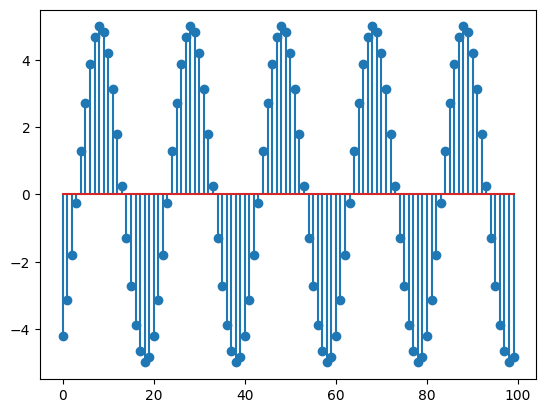

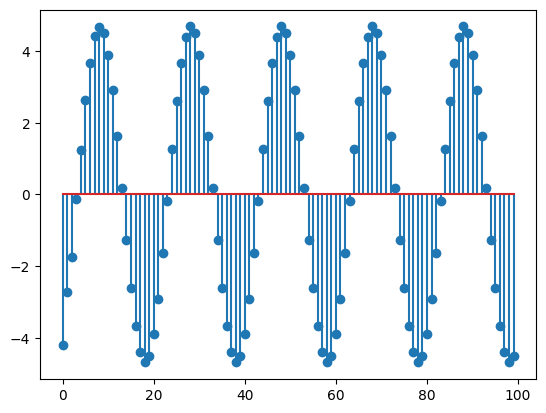

In [25]:
plt.stem(n, x)
plt.figure()
plt.stem(n, y1)

In [9]:
f0/fs

9.765625